# Eksperimen Q-Learning Scenario C

State: `(current_node, previous_node, progress_bin)` — agen juga mengetahui arah kedatangan.

Notebook ini tidak menduplikasi implementasi. Semua konfigurasi, download/load OSM, environment, reward, Q-Learning, metrik, grafik, dan peta berasal dari `rute_lari_core.py`.

In [10]:
%pip install -q "osmnx>=2.0" networkx numpy pandas geopandas shapely folium matplotlib pyproj

Note: you may need to restart the kernel to use updated packages.


## 1. Muat graf dengan core bersama

Jika GraphML belum ada, fungsi berikut mengunduh data OSM dengan konfigurasi yang sama seperti notebook analisis. Jika sudah ada, GraphML dimuat tanpa mengunduh ulang.

In [34]:
import importlib
import rute_lari_core

# Memuat ulang core agar perubahan grafik terbaru terbaca tanpa restart kernel.
importlib.reload(rute_lari_core)

from rute_lari_core import (
    load_or_download_graph,
    run_scenario_experiment,
    EPISODES,
    SEEDS,
)

G, START_NODE, GRAPH_PATH, downloaded_now = load_or_download_graph()

print(f'Graf: {G.number_of_nodes():,} node, {G.number_of_edges():,} edge')
print(f'Node start: {START_NODE}')
print(f'GraphML: {GRAPH_PATH}')
print('Sumber graf:', 'download baru' if downloaded_now else 'GraphML yang sudah ada')
print(f'Training: {len(SEEDS)} seed × {EPISODES:,} episode')

Graf: 8,027 node, 21,374 edge
Node start: 1720975931
GraphML: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/data_osm_5km/graf_jalan_kaki_5km.graphml
Sumber graf: GraphML yang sudah ada
Training: 5 seed × 2,500 episode


## 2. Eksperimen sensitivitas dengan epsilon dinamis

Bagian ini mempertahankan eksperimen awal Scenario C. Setiap cell melatih ulang lima seed dari awal; graf, reward, penyaringan ruas legal, state, seed, dan evaluasi greedy sama. Pada bagian ini epsilon turun dari 1,00 ke 0,05 selama **seluruh** jumlah episode training. Karena itu hasil 10k--50k dipakai sebagai eksplorasi awal, bukan pembandingan final antar durasi training.

Jalankan cell secara berurutan. Eksperimen lengkap mencakup 5 seed × (10.000 + 20.000 + 30.000 + 40.000 + 50.000) = 750.000 episode untuk Scenario C. Artefak setiap percobaan disimpan pada folder terpisah agar tidak saling menimpa.


### 2.1 Training 10.000 episode


In [ ]:
import importlib
# Memastikan kernel memakai versi core terbaru yang mendukung parameter episodes.
importlib.reload(rute_lari_core)

result_c_10000 = rute_lari_core.run_scenario_experiment(
    G, START_NODE, 'C', episodes=10_000,
    result_subdir='sensitivitas_episode_10000_C',
)


### 2.2 Training 20.000 episode


In [ ]:
import importlib
# Memastikan kernel memakai versi core terbaru yang mendukung parameter episodes.
importlib.reload(rute_lari_core)

result_c_20000 = rute_lari_core.run_scenario_experiment(
    G, START_NODE, 'C', episodes=20_000,
    result_subdir='sensitivitas_episode_20000_C',
)


### 2.3 Training 30.000 episode


In [ ]:
import importlib
# Memastikan kernel memakai versi core terbaru yang mendukung parameter episodes.
importlib.reload(rute_lari_core)

result_c_30000 = rute_lari_core.run_scenario_experiment(
    G, START_NODE, 'C', episodes=30_000,
    result_subdir='sensitivitas_episode_30000_C',
)


### 2.4 Training 40.000 episode


In [ ]:
import importlib
# Memastikan kernel memakai versi core terbaru yang mendukung parameter episodes.
importlib.reload(rute_lari_core)

result_c_40000 = rute_lari_core.run_scenario_experiment(
    G, START_NODE, 'C', episodes=40_000,
    result_subdir='sensitivitas_episode_40000_C',
)


### 2.5 Training 50.000 episode


Menjalankan Scenario C: 5 seed x 300,000 episode
seed=0: over_distance, 5.50 km, is_loop=False
seed=1: success, 5.09 km, is_loop=True
seed=2: success, 5.01 km, is_loop=True
seed=3: over_distance, 5.60 km, is_loop=False
seed=4: success, 5.17 km, is_loop=True
Tampilan vertikal metrik evaluasi utama per seed


seed,0,1,2,3,4
is_loop,False,True,True,False,True
total_distance_m,5503.339203,5090.512149,5007.821658,5596.909052,5167.382392
absolute_distance_error_m,503.339203,90.512149,7.821658,596.909052,167.382392
total_reward,-104.692241,73.609328,74.059478,-32.055221,81.378617
mean_comfort,0.779834,0.76394,0.778842,0.784911,0.764768
return_progress_ratio,0.75641,0.638889,0.756098,0.671642,0.705882
distance_to_start_at_end_m,606.581386,0.0,0.0,714.117096,0.0
closing_action_available,False,True,True,False,True
termination_reason,over_distance,success,success,over_distance,success


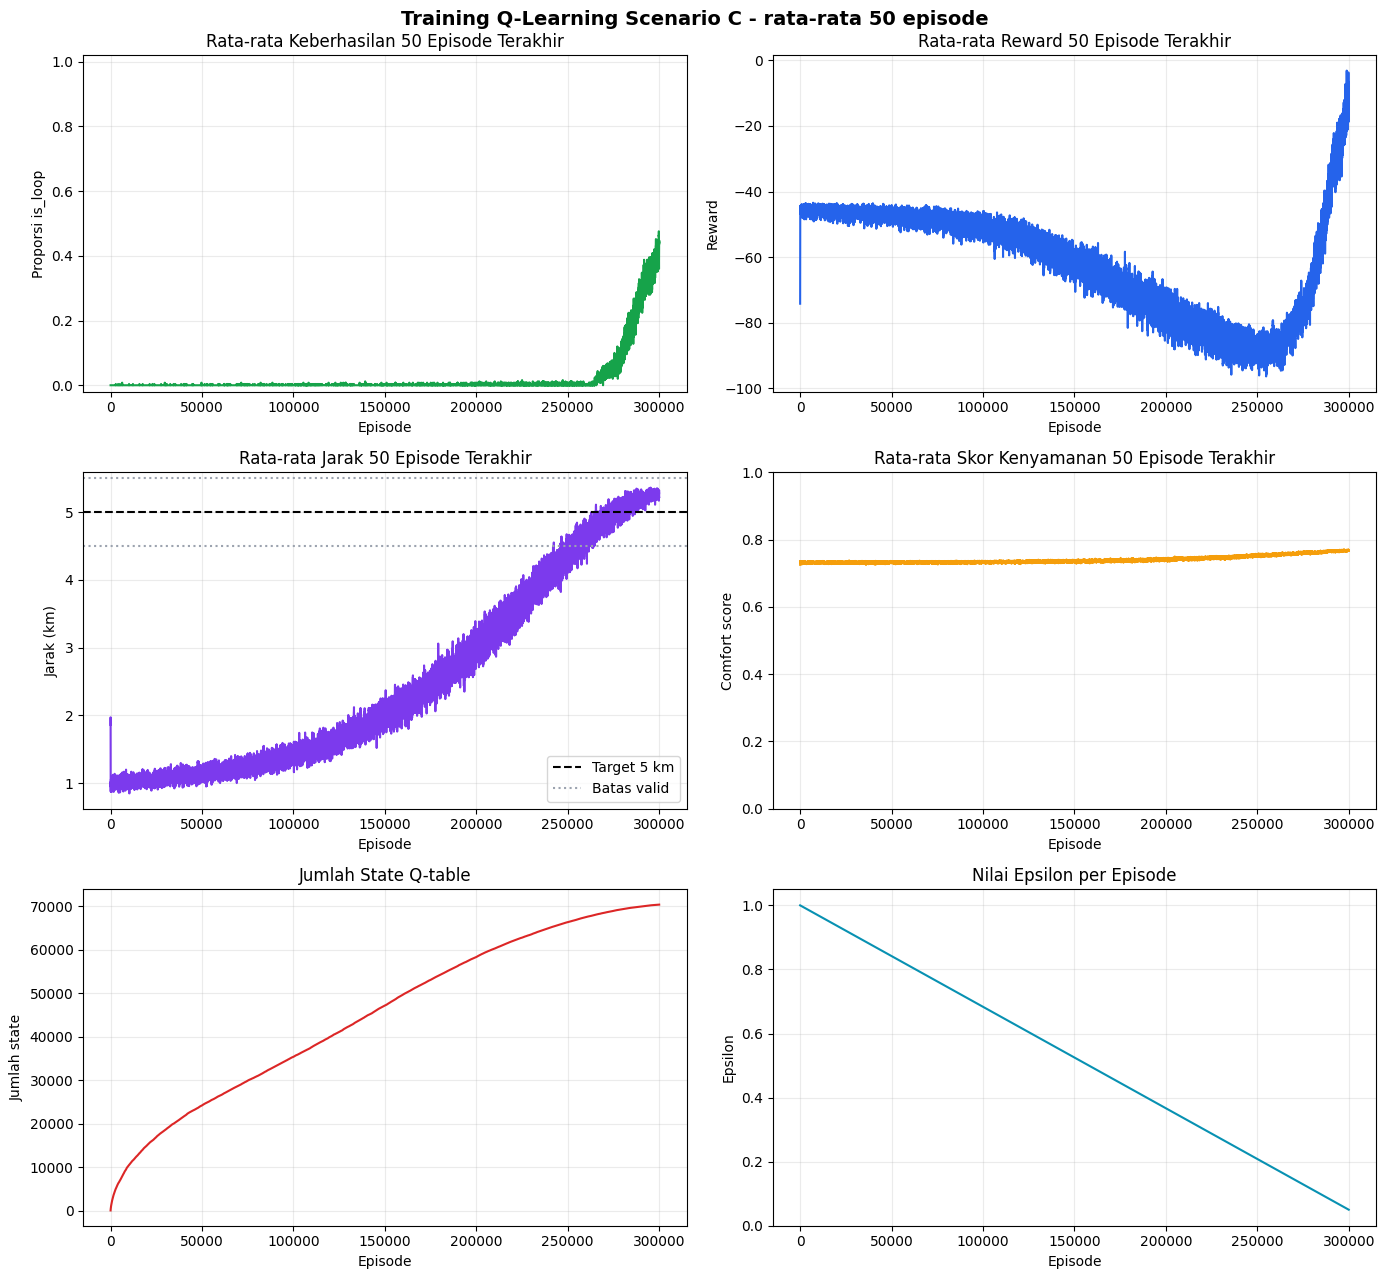

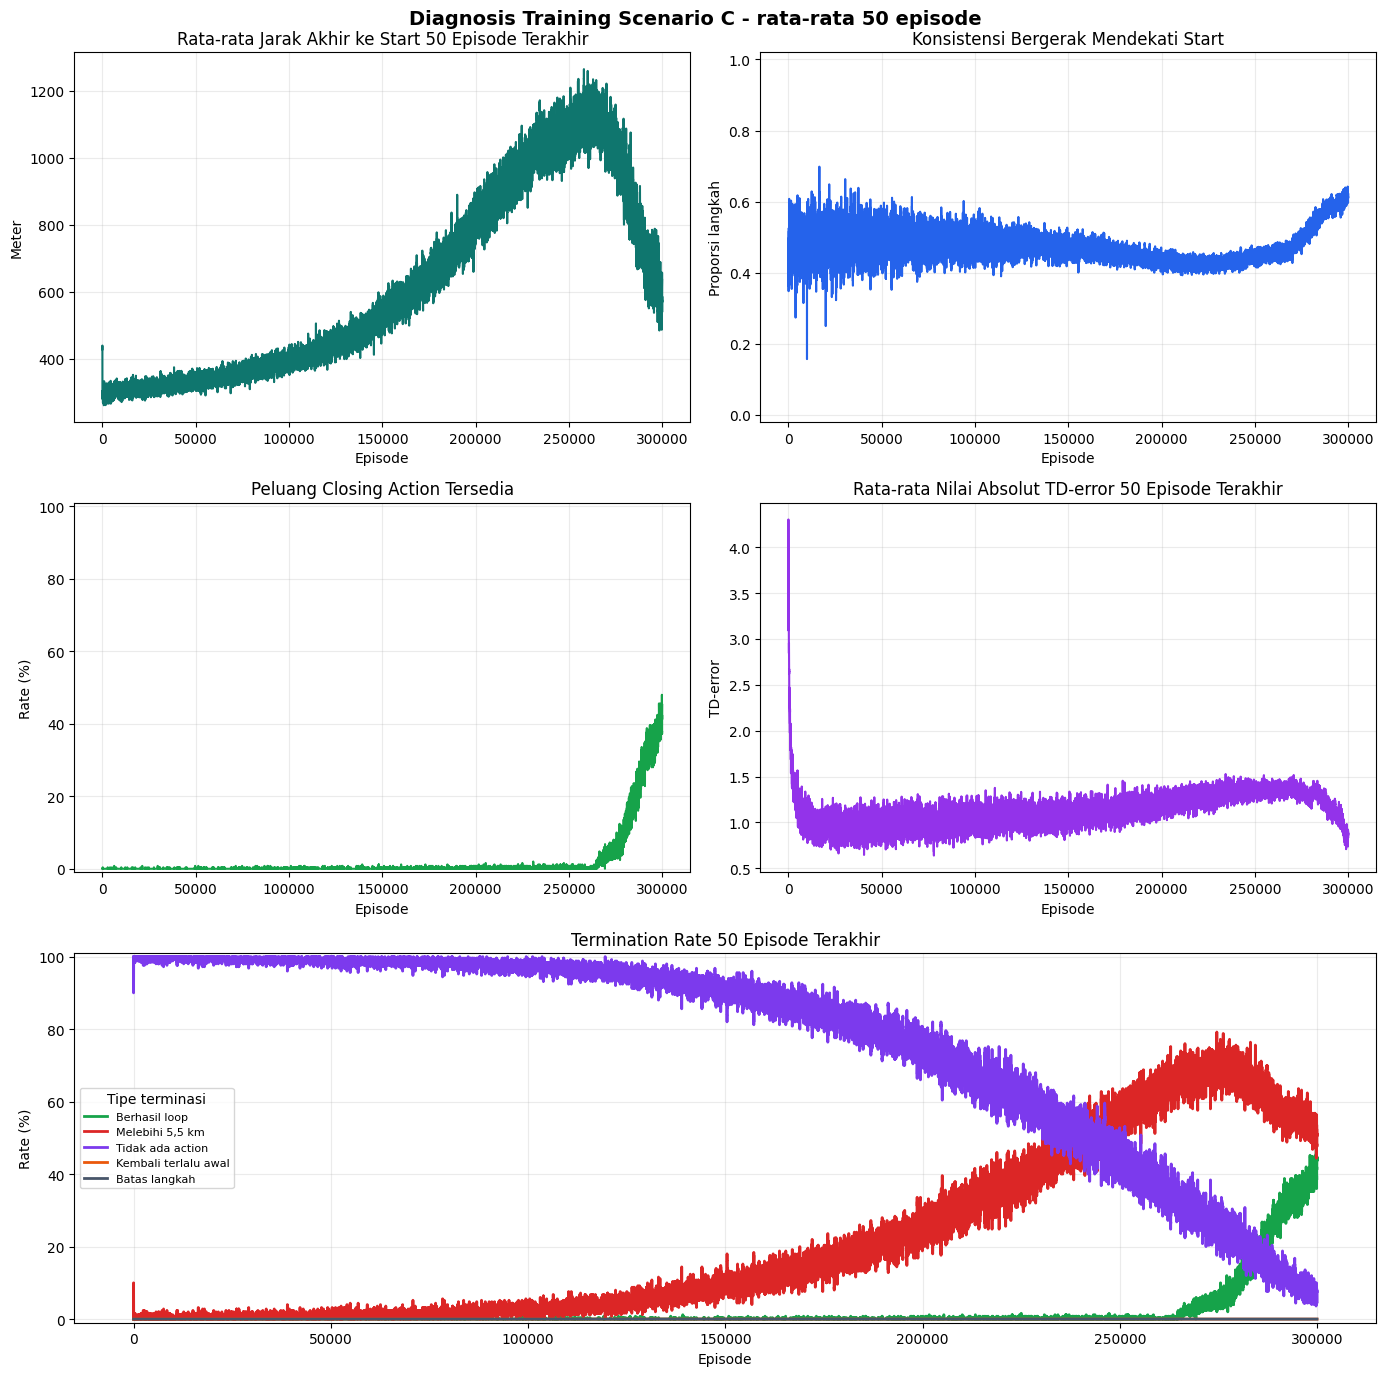

=== Q-TABLE / SEED YANG DIPILIH UNTUK PETA ===
Scenario: C; seed: 2
Metrik: is_loop=True, jarak=5007.82 m, galat=7.82 m, comfort=0.779, return_progress=0.756, jarak akhir ke start=0.00 m, terminasi=success
Alasan: Dipilih dari 3 loop valid: galat jarak paling kecil; jika setara, comfort lalu return progress lebih tinggi.


History: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_50000_C/training_history_C.csv
Evaluasi: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_50000_C/evaluation_metrics_C.csv
Diagnosis: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_50000_C/diagnosis_metrics_C.csv
Termination rate training: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_50000_C/termination_rates_training_C.csv
Termination rate evaluasi: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_50000_C/termination_rates_evaluation_C.csv
Grafik training utama: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/t

In [54]:
import importlib
# Memastikan kernel memakai versi core terbaru yang mendukung parameter episodes.
importlib.reload(rute_lari_core)

result_c_50000 = rute_lari_core.run_scenario_experiment(
    G, START_NODE, 'C', episodes=50_000,
    result_subdir='sensitivitas_episode_50000_C',
)


### 2.6 Ringkasan perbandingan

Tabel dan grafik berikut memakai evaluasi greedy lima seed dari setiap jumlah episode. `success_rate_greedy` adalah proporsi seed yang membentuk loop valid. Bandingkan terutama keberhasilan loop, galat jarak, return progress ratio, dan peluang closing action tersedia.


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

episode_results = {
    10_000: result_c_10000,
    20_000: result_c_20000,
    30_000: result_c_30000,
    40_000: result_c_40000,
    50_000: result_c_50000,
}

summary_rows = []
for episodes, result in episode_results.items():
    metrics = result['metrics']
    summary_rows.append({
        'episodes': episodes,
        'success_rate_greedy': metrics['is_loop'].mean(),
        'mean_distance_error_m': metrics['absolute_distance_error_m'].mean(),
        'mean_total_reward': metrics['total_reward'].mean(),
        'mean_comfort': metrics['mean_comfort'].mean(),
        'mean_return_progress_ratio': metrics['return_progress_ratio'].mean(),
        'closing_action_available_rate': metrics['closing_action_available'].mean(),
    })

episode_sensitivity_df = pd.DataFrame(summary_rows).sort_values('episodes')
display(episode_sensitivity_df)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
plots = [
    ('success_rate_greedy', 'Keberhasilan Loop pada Evaluasi Greedy', 'Proporsi seed'),
    ('mean_distance_error_m', 'Rata-rata Galat Jarak', 'Meter'),
    ('mean_return_progress_ratio', 'Rata-rata Return Progress Ratio', 'Proporsi langkah'),
    ('closing_action_available_rate', 'Peluang Closing Action Tersedia', 'Proporsi seed'),
]
for axis, (column, title, ylabel) in zip(axes.flat, plots):
    axis.plot(episode_sensitivity_df['episodes'], episode_sensitivity_df[column], marker='o')
    axis.set(title=title, xlabel='Jumlah episode training', ylabel=ylabel)
    axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 3. Sensitivitas lanjutan dengan epsilon decay tetap

"
            f"Bagian ini menguji Scenario C pada 50.000, 100.000, 200.000, dan 400.000 episode. Semua percobaan memakai `epsilon_decay_episodes=50_000`: epsilon turun dari 1,00 ke 0,05 hanya pada 50.000 episode pertama, lalu tetap 0,05 sampai training selesai.

"
            f"Dengan desain ini, perbedaan hasil 50k, 100k, 200k, dan 400k dapat dibaca sebagai dampak tambahan durasi training setelah fase eksplorasi utama selesai. Setiap cell tetap melatih lima seed dari awal dan menyimpan artefak pada folder yang berbeda. Training 50k dijalankan ulang agar rangkaian ini mandiri dan dapat direproduksi, walaupun jadwal epsilon-nya secara matematis sama dengan eksperimen dinamis 50k.


### 3.1 Training 50,000 episode dengan epsilon decay 50.000


Menjalankan Scenario C: 5 seed x 50,000 episode
Jadwal epsilon: turun selama 50,000 episode, lalu tetap 0.05
seed=0: success, 5.33 km, is_loop=True
seed=1: over_distance, 5.56 km, is_loop=False
seed=2: over_distance, 5.52 km, is_loop=False
seed=3: success, 4.82 km, is_loop=True
seed=4: over_distance, 5.52 km, is_loop=False
Tampilan vertikal metrik evaluasi utama per seed


seed,0,1,2,3,4
is_loop,True,False,False,True,False
total_distance_m,5325.293749,5563.763006,5522.265793,4817.120312,5517.331307
absolute_distance_error_m,325.293749,563.763006,522.265793,182.879688,517.331307
total_reward,94.972197,-40.888742,-73.045352,94.495602,-55.52484
mean_comfort,0.7037,0.714527,0.680621,0.70488,0.719132
return_progress_ratio,0.857143,0.355556,0.581395,0.868421,0.413043
distance_to_start_at_end_m,0.0,1344.104659,1368.309026,0.0,1041.37972
closing_action_available,True,False,False,True,False
termination_reason,success,over_distance,over_distance,success,over_distance


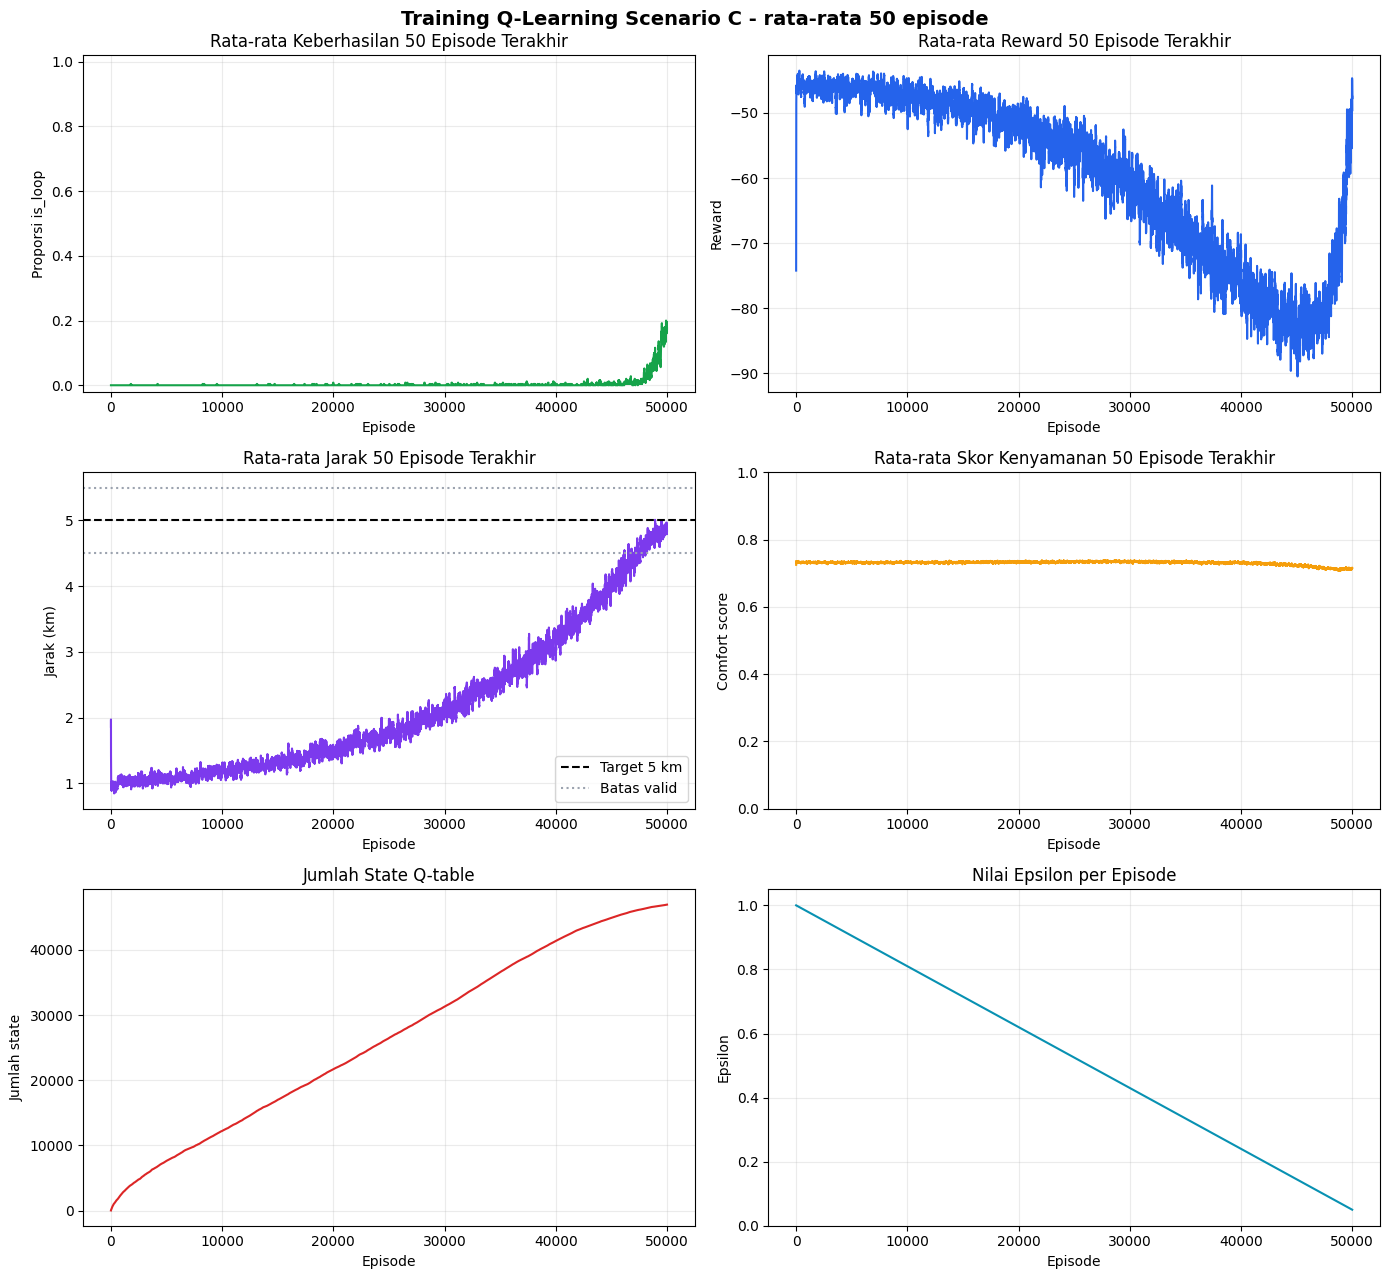

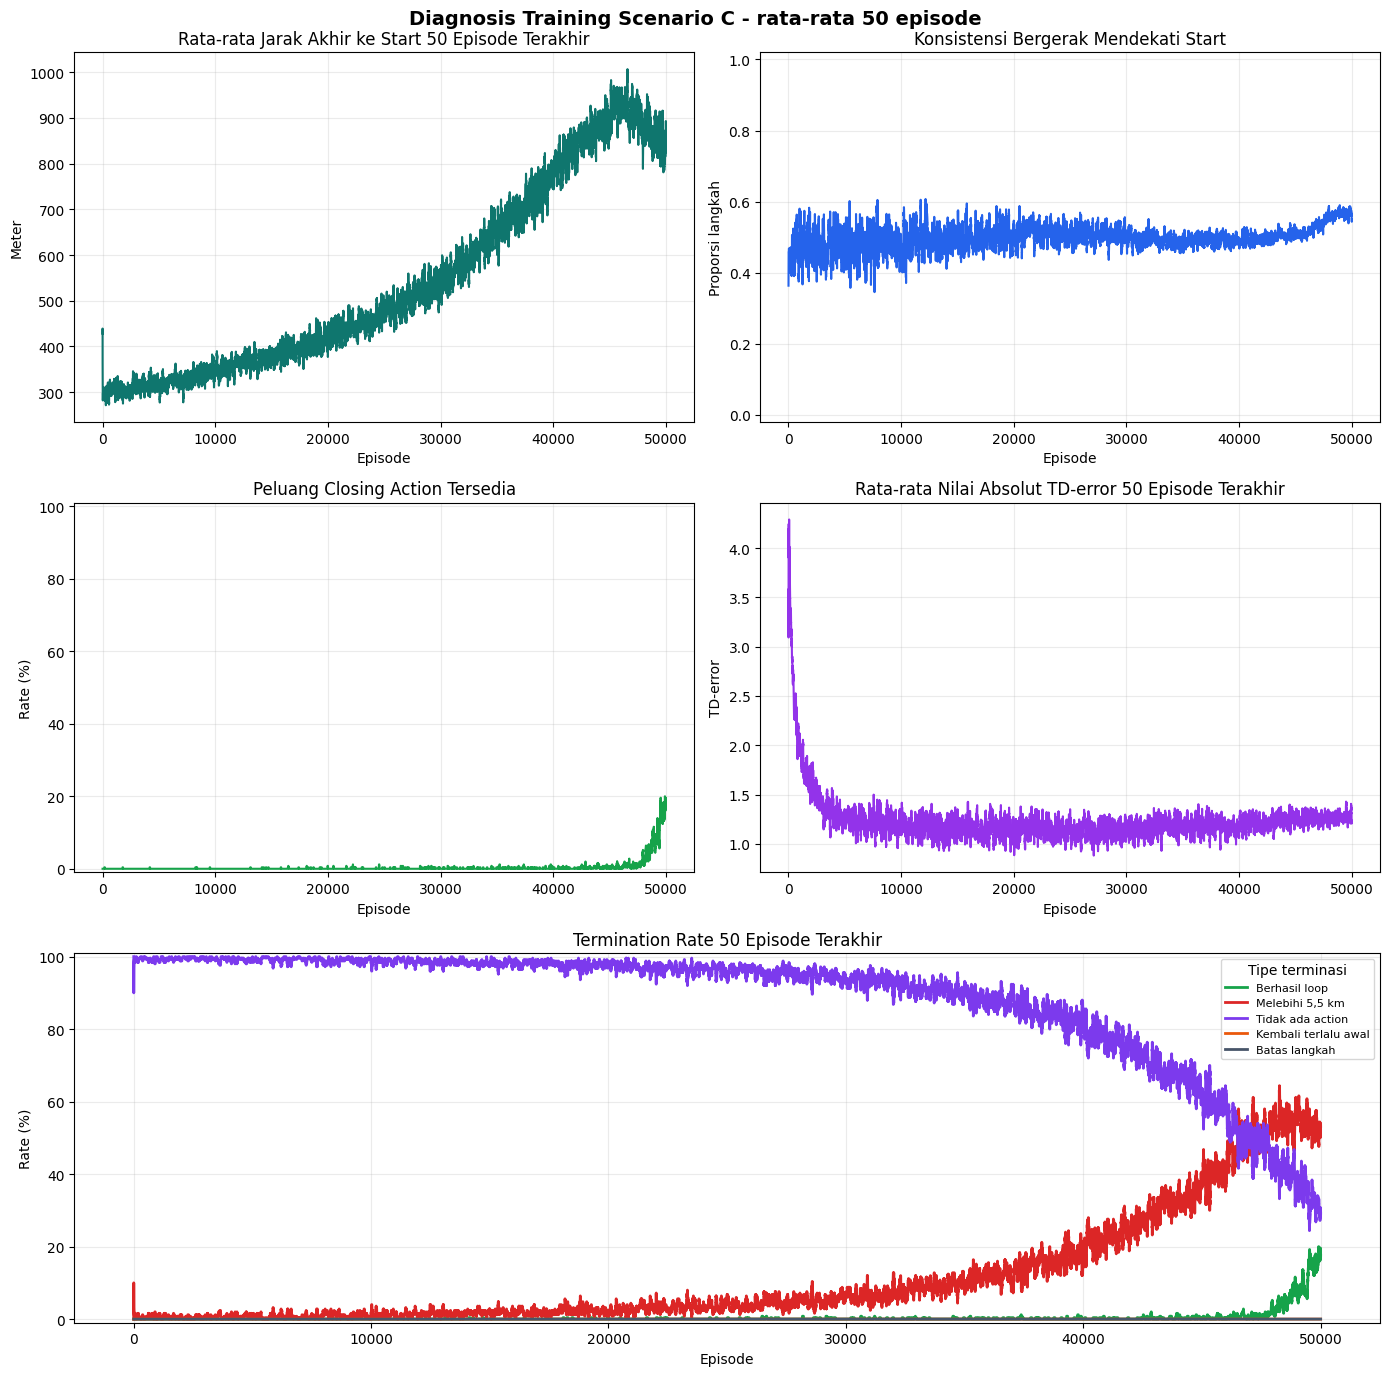

=== Q-TABLE / SEED YANG DIPILIH UNTUK PETA ===
Scenario: C; seed: 3
Metrik: is_loop=True, jarak=4817.12 m, galat=182.88 m, comfort=0.705, return_progress=0.868, jarak akhir ke start=0.00 m, terminasi=success
Alasan: Dipilih dari 2 loop valid: galat jarak paling kecil; jika setara, comfort lalu return progress lebih tinggi.


History: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_epsilon_tetap_50000_episode_50000_C/training_history_C.csv
Evaluasi: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_epsilon_tetap_50000_episode_50000_C/evaluation_metrics_C.csv
Diagnosis: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_epsilon_tetap_50000_episode_50000_C/diagnosis_metrics_C.csv
Termination rate training: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_epsilon_tetap_50000_episode_50000_C/termination_rates_training_C.csv
Termination rate evaluasi: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_epsilon_tetap_50000_episode_50000_C/termination_rates_evaluation_C.csv
Grafik

In [55]:
import importlib
# Memuat ulang core agar parameter epsilon_decay_episodes versi terbaru digunakan.
importlib.reload(rute_lari_core)

result_c_fixed_50000 = rute_lari_core.run_scenario_experiment(
    G, START_NODE, 'C',
    episodes=50_000,
    # Epsilon turun hanya pada 50.000 episode pertama, kemudian tetap 0,05.
    epsilon_decay_episodes=50_000,
    result_subdir='sensitivitas_epsilon_tetap_50000_episode_50000_C',
)


### 3.2 Training 100,000 episode dengan epsilon decay 50.000


Menjalankan Scenario C: 5 seed x 100,000 episode
Jadwal epsilon: turun selama 50,000 episode, lalu tetap 0.05
seed=0: success, 5.04 km, is_loop=True
seed=1: success, 4.51 km, is_loop=True
seed=2: success, 4.84 km, is_loop=True
seed=3: success, 4.82 km, is_loop=True
seed=4: success, 4.54 km, is_loop=True
Tampilan vertikal metrik evaluasi utama per seed


seed,0,1,2,3,4
is_loop,True,True,True,True,True
total_distance_m,5039.444003,4505.214771,4836.700628,4822.786549,4538.181404
absolute_distance_error_m,39.444003,494.785229,163.299372,177.213451,461.818596
total_reward,93.68024,82.203744,93.225139,93.094838,73.205197
mean_comfort,0.701947,0.70247,0.701003,0.698881,0.691597
return_progress_ratio,0.828571,0.76,0.848485,0.861111,0.62963
distance_to_start_at_end_m,0.0,0.0,0.0,0.0,0.0
closing_action_available,True,True,True,True,True
termination_reason,success,success,success,success,success


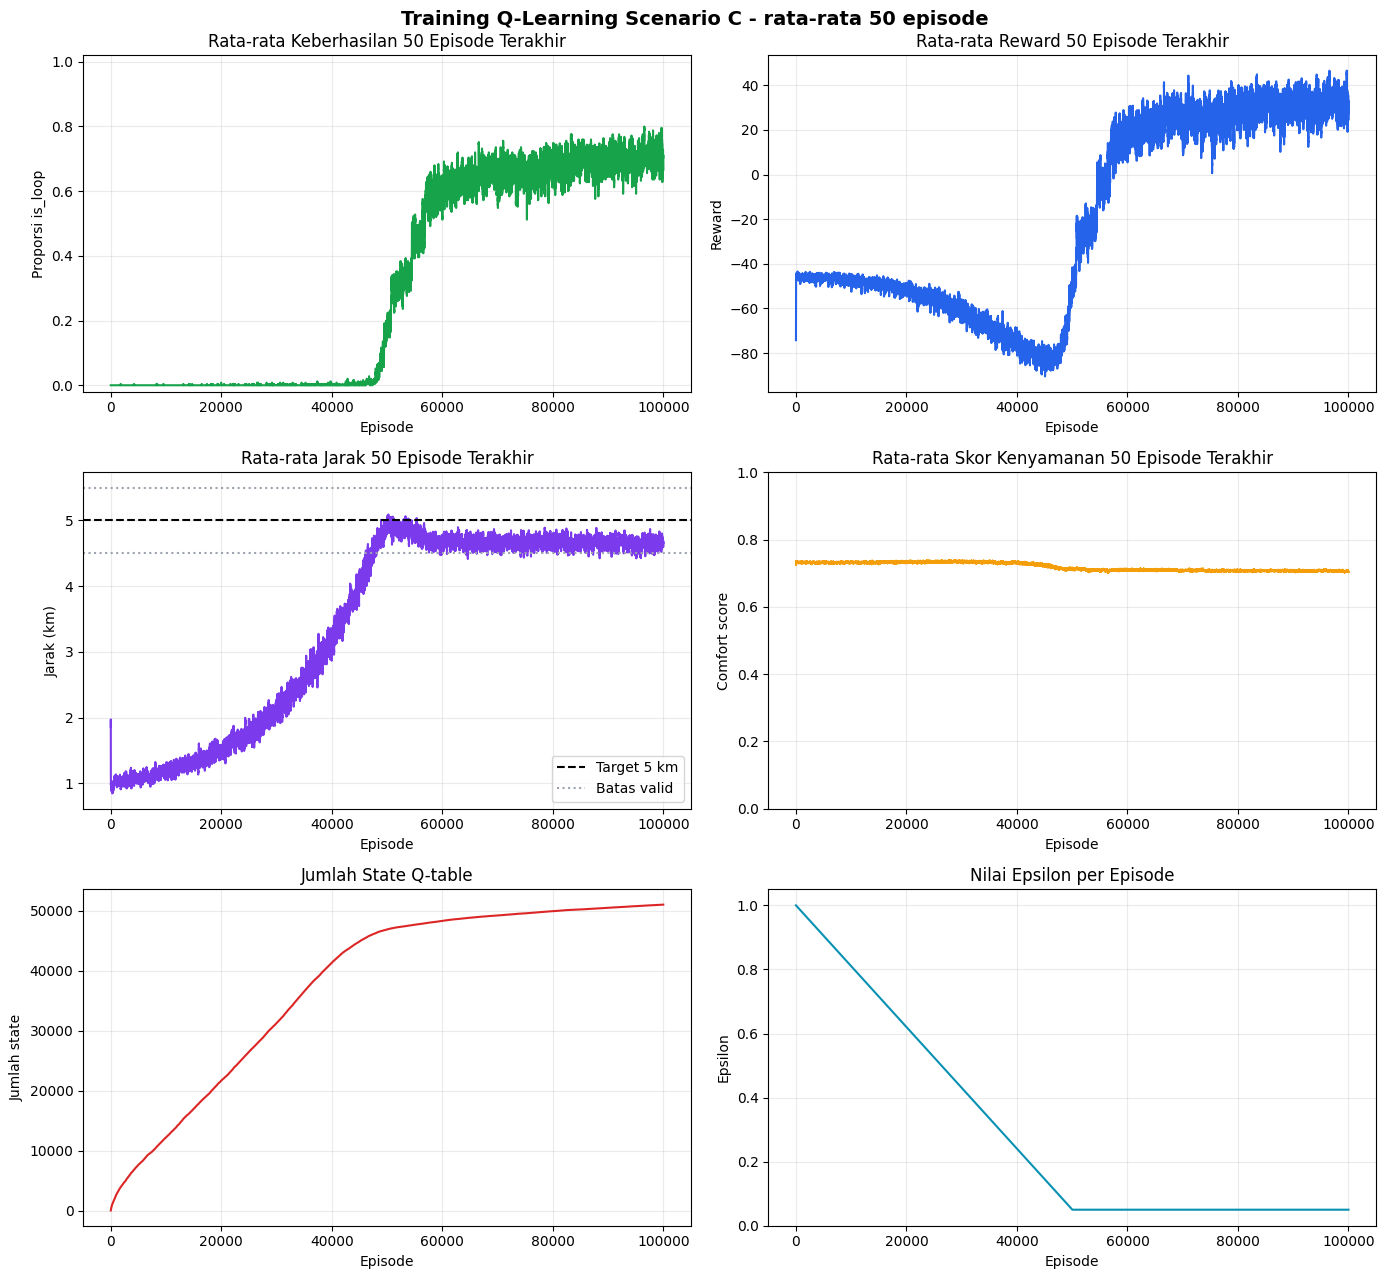

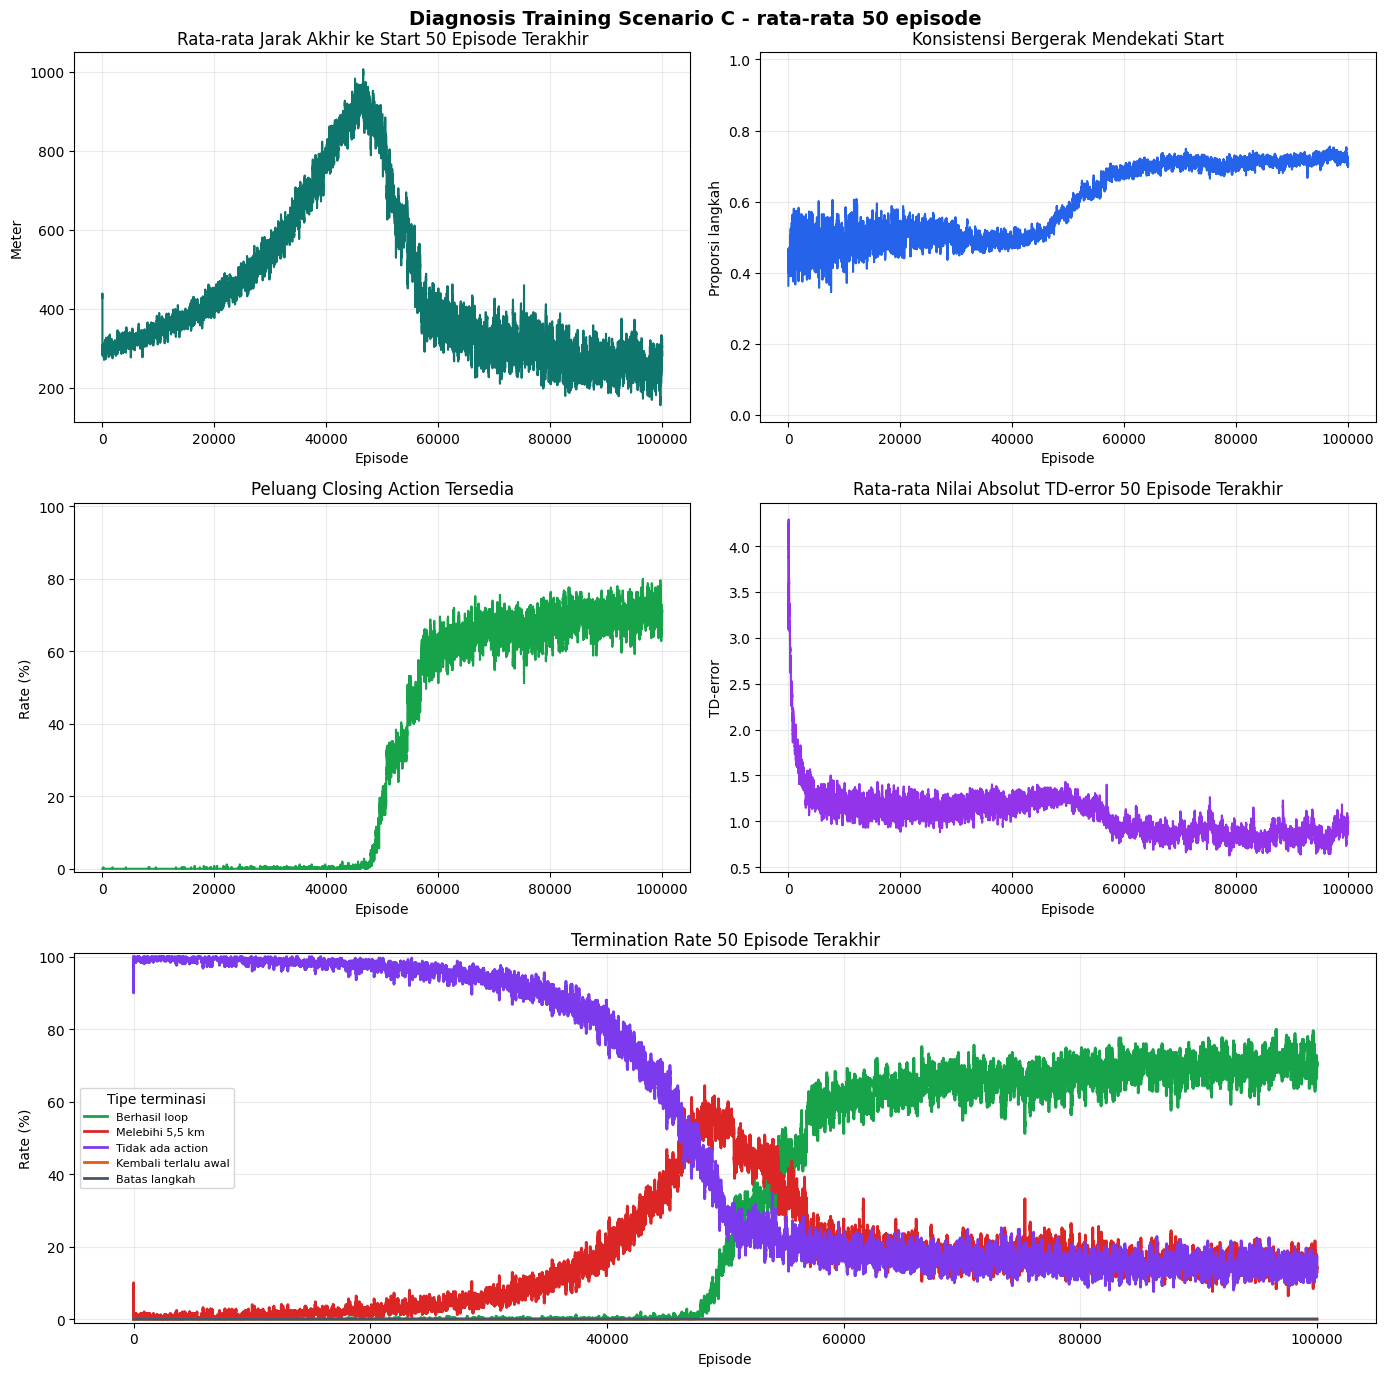

=== Q-TABLE / SEED YANG DIPILIH UNTUK PETA ===
Scenario: C; seed: 0
Metrik: is_loop=True, jarak=5039.44 m, galat=39.44 m, comfort=0.702, return_progress=0.829, jarak akhir ke start=0.00 m, terminasi=success
Alasan: Dipilih dari 5 loop valid: galat jarak paling kecil; jika setara, comfort lalu return progress lebih tinggi.


History: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_epsilon_tetap_50000_episode_100000_C/training_history_C.csv
Evaluasi: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_epsilon_tetap_50000_episode_100000_C/evaluation_metrics_C.csv
Diagnosis: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_epsilon_tetap_50000_episode_100000_C/diagnosis_metrics_C.csv
Termination rate training: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_epsilon_tetap_50000_episode_100000_C/termination_rates_training_C.csv
Termination rate evaluasi: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_epsilon_tetap_50000_episode_100000_C/termination_rates_evaluation_C.csv
G

In [56]:
import importlib
# Memuat ulang core agar parameter epsilon_decay_episodes versi terbaru digunakan.
importlib.reload(rute_lari_core)

result_c_fixed_100000 = rute_lari_core.run_scenario_experiment(
    G, START_NODE, 'C',
    episodes=100_000,
    # Epsilon turun hanya pada 50.000 episode pertama, kemudian tetap 0,05.
    epsilon_decay_episodes=50_000,
    result_subdir='sensitivitas_epsilon_tetap_50000_episode_100000_C',
)


### 3.3 Training 200,000 episode dengan epsilon decay 50.000


Menjalankan Scenario C: 5 seed x 200,000 episode
Jadwal epsilon: turun selama 50,000 episode, lalu tetap 0.05
seed=0: success, 4.80 km, is_loop=True
seed=1: success, 4.78 km, is_loop=True
seed=2: success, 4.82 km, is_loop=True
seed=3: success, 4.56 km, is_loop=True
seed=4: success, 4.73 km, is_loop=True
Tampilan vertikal metrik evaluasi utama per seed


seed,0,1,2,3,4
is_loop,True,True,True,True,True
total_distance_m,4795.766924,4776.189978,4823.664255,4558.119084,4725.462599
absolute_distance_error_m,204.233076,223.810022,176.335745,441.880916,274.537401
total_reward,90.724581,75.879973,93.127034,92.398653,82.199968
mean_comfort,0.691653,0.700013,0.699512,0.701017,0.703756
return_progress_ratio,0.793103,0.703704,0.848485,0.83871,0.666667
distance_to_start_at_end_m,0.0,0.0,0.0,0.0,0.0
closing_action_available,True,True,True,True,True
termination_reason,success,success,success,success,success


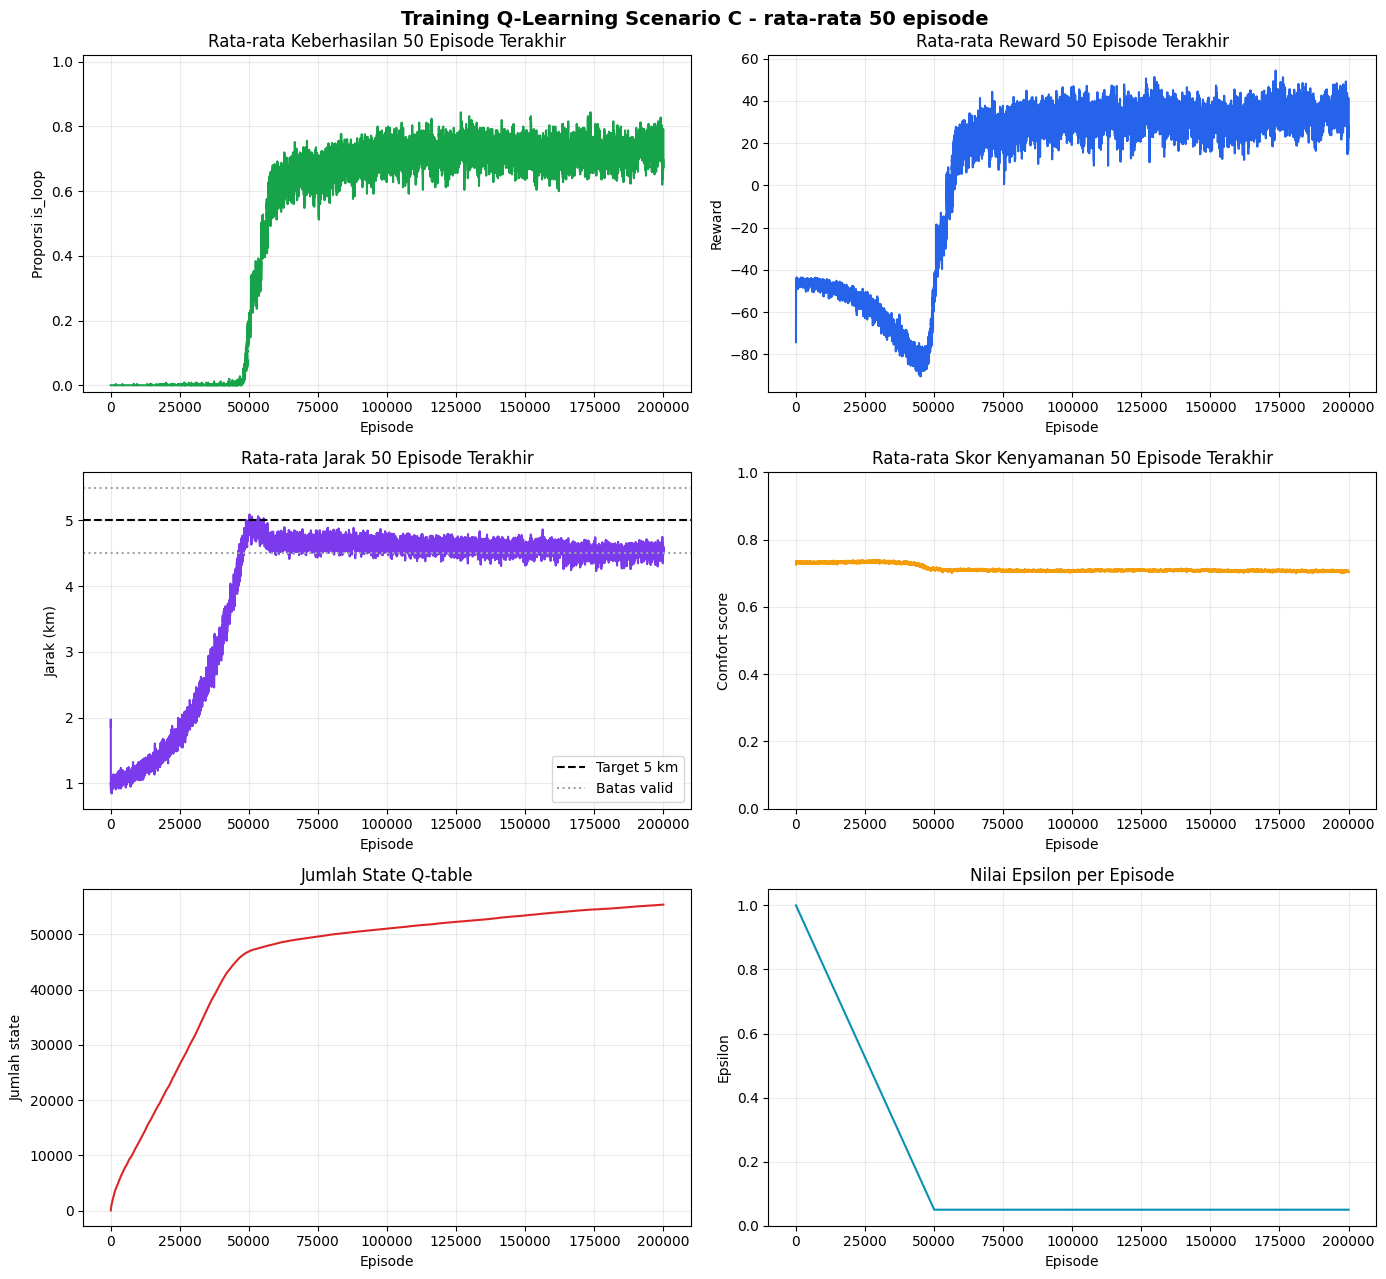

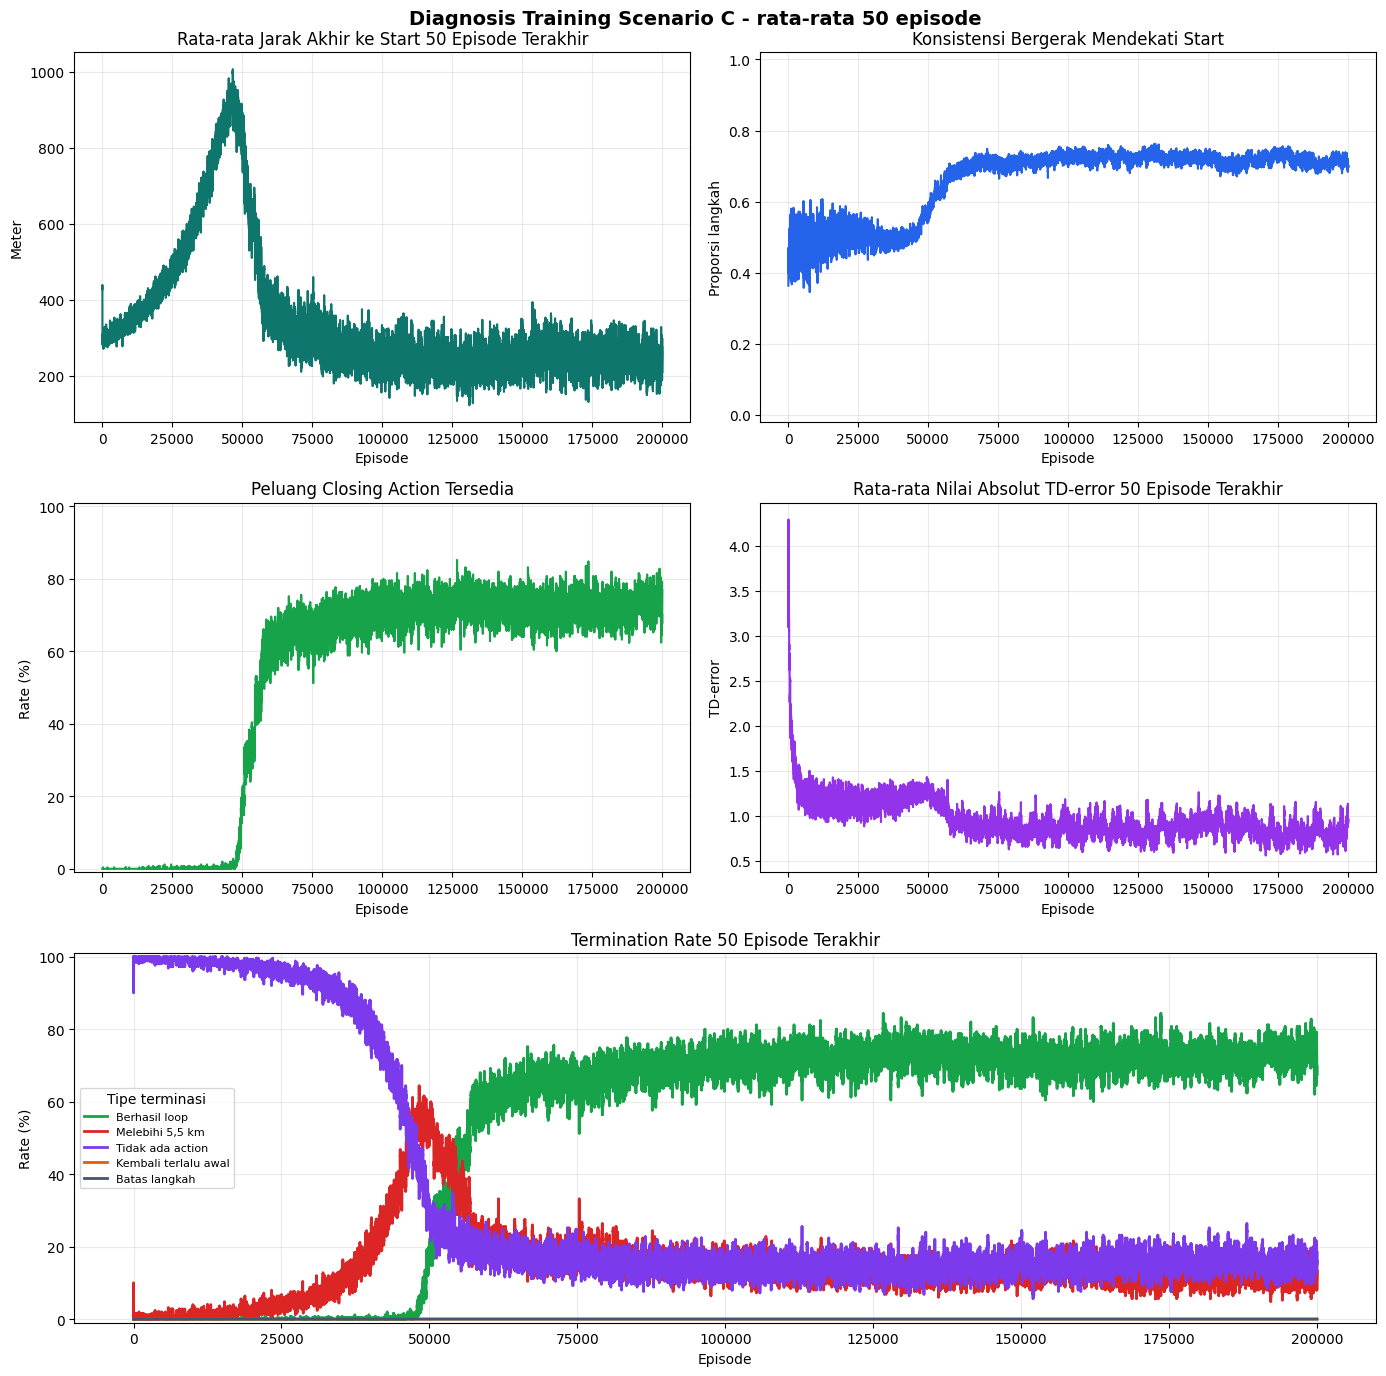

=== Q-TABLE / SEED YANG DIPILIH UNTUK PETA ===
Scenario: C; seed: 2
Metrik: is_loop=True, jarak=4823.66 m, galat=176.34 m, comfort=0.700, return_progress=0.848, jarak akhir ke start=0.00 m, terminasi=success
Alasan: Dipilih dari 5 loop valid: galat jarak paling kecil; jika setara, comfort lalu return progress lebih tinggi.


History: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_epsilon_tetap_50000_episode_200000_C/training_history_C.csv
Evaluasi: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_epsilon_tetap_50000_episode_200000_C/evaluation_metrics_C.csv
Diagnosis: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_epsilon_tetap_50000_episode_200000_C/diagnosis_metrics_C.csv
Termination rate training: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_epsilon_tetap_50000_episode_200000_C/termination_rates_training_C.csv
Termination rate evaluasi: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_epsilon_tetap_50000_episode_200000_C/termination_rates_evaluation_C.csv
G

In [57]:
import importlib
# Memuat ulang core agar parameter epsilon_decay_episodes versi terbaru digunakan.
importlib.reload(rute_lari_core)

result_c_fixed_200000 = rute_lari_core.run_scenario_experiment(
    G, START_NODE, 'C',
    episodes=200_000,
    # Epsilon turun hanya pada 50.000 episode pertama, kemudian tetap 0,05.
    epsilon_decay_episodes=50_000,
    result_subdir='sensitivitas_epsilon_tetap_50000_episode_200000_C',
)


### 3.4 Training 400,000 episode dengan epsilon decay 50.000


Menjalankan Scenario C: 5 seed x 400,000 episode
Jadwal epsilon: turun selama 50,000 episode, lalu tetap 0.05
seed=0: success, 4.51 km, is_loop=True
seed=1: success, 4.50 km, is_loop=True
seed=2: success, 4.82 km, is_loop=True
seed=3: success, 4.55 km, is_loop=True
seed=4: success, 4.81 km, is_loop=True
Tampilan vertikal metrik evaluasi utama per seed


seed,0,1,2,3,4
is_loop,True,True,True,True,True
total_distance_m,4506.735544,4501.345774,4823.664255,4548.401259,4810.357862
absolute_distance_error_m,493.264456,498.654226,176.335745,451.598741,189.642138
total_reward,88.817942,88.286574,93.127034,89.92943,48.377386
mean_comfort,0.657956,0.656406,0.699512,0.689746,0.644555
return_progress_ratio,0.772727,0.782609,0.848485,0.666667,0.68
distance_to_start_at_end_m,0.0,0.0,0.0,0.0,0.0
closing_action_available,True,True,True,True,True
termination_reason,success,success,success,success,success


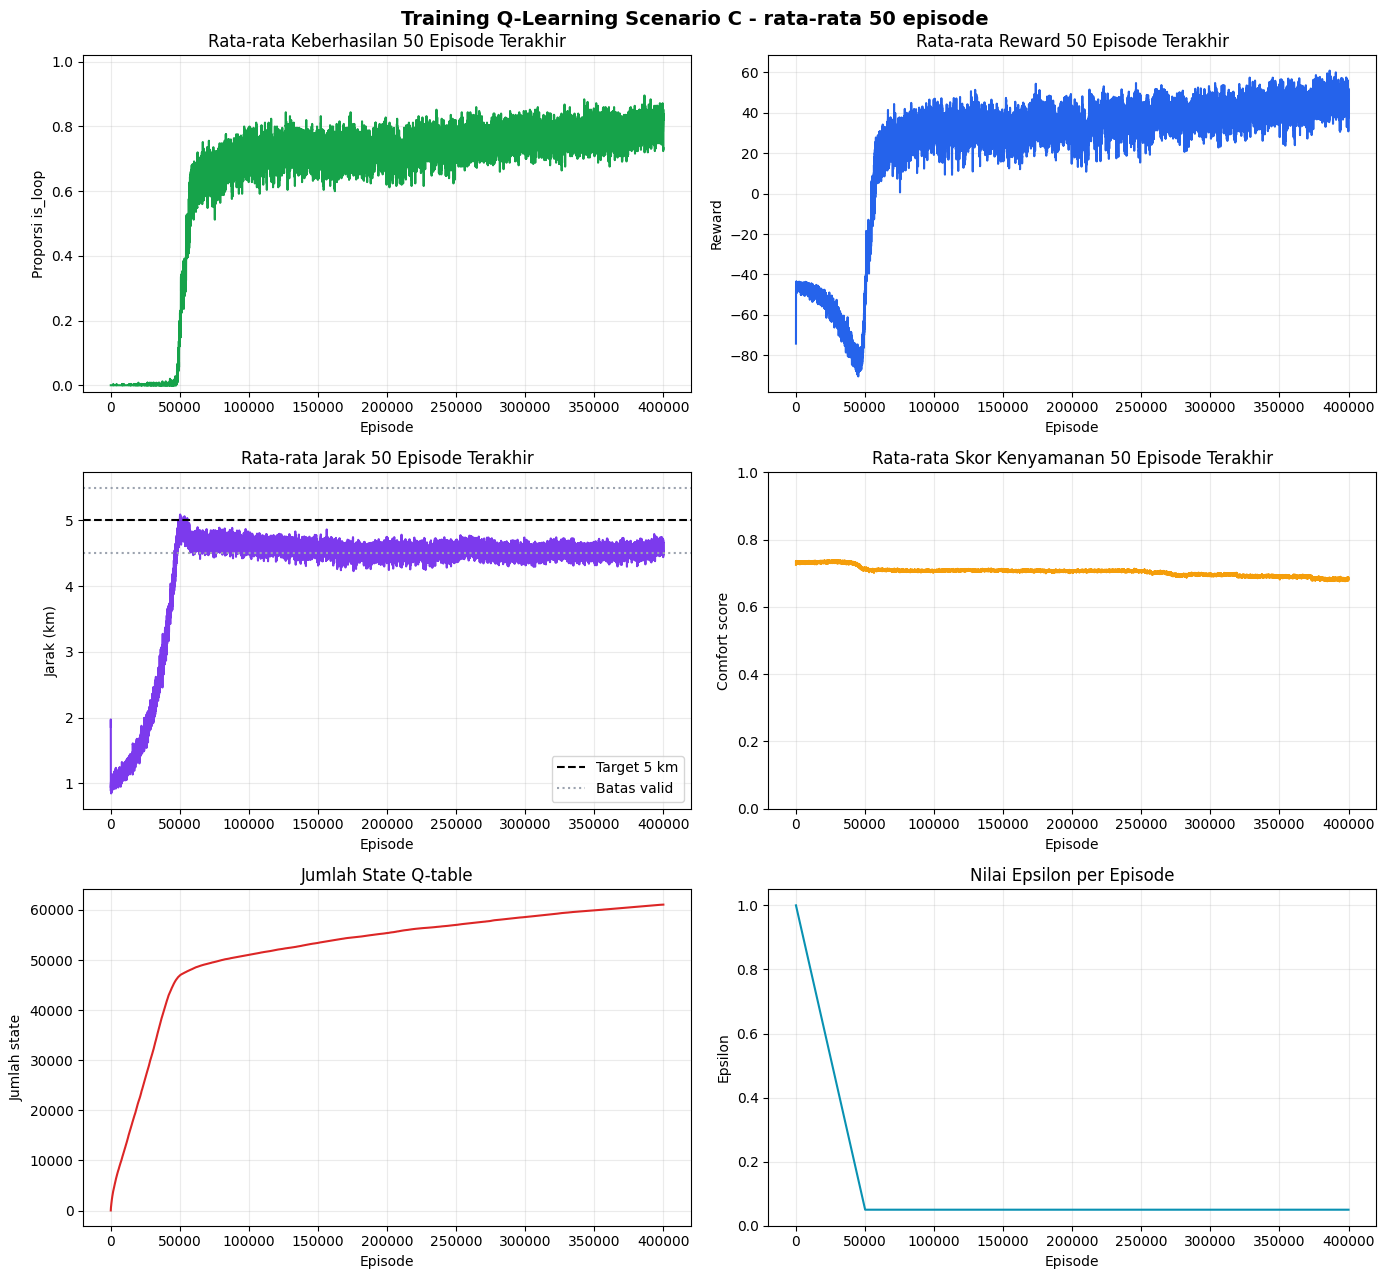

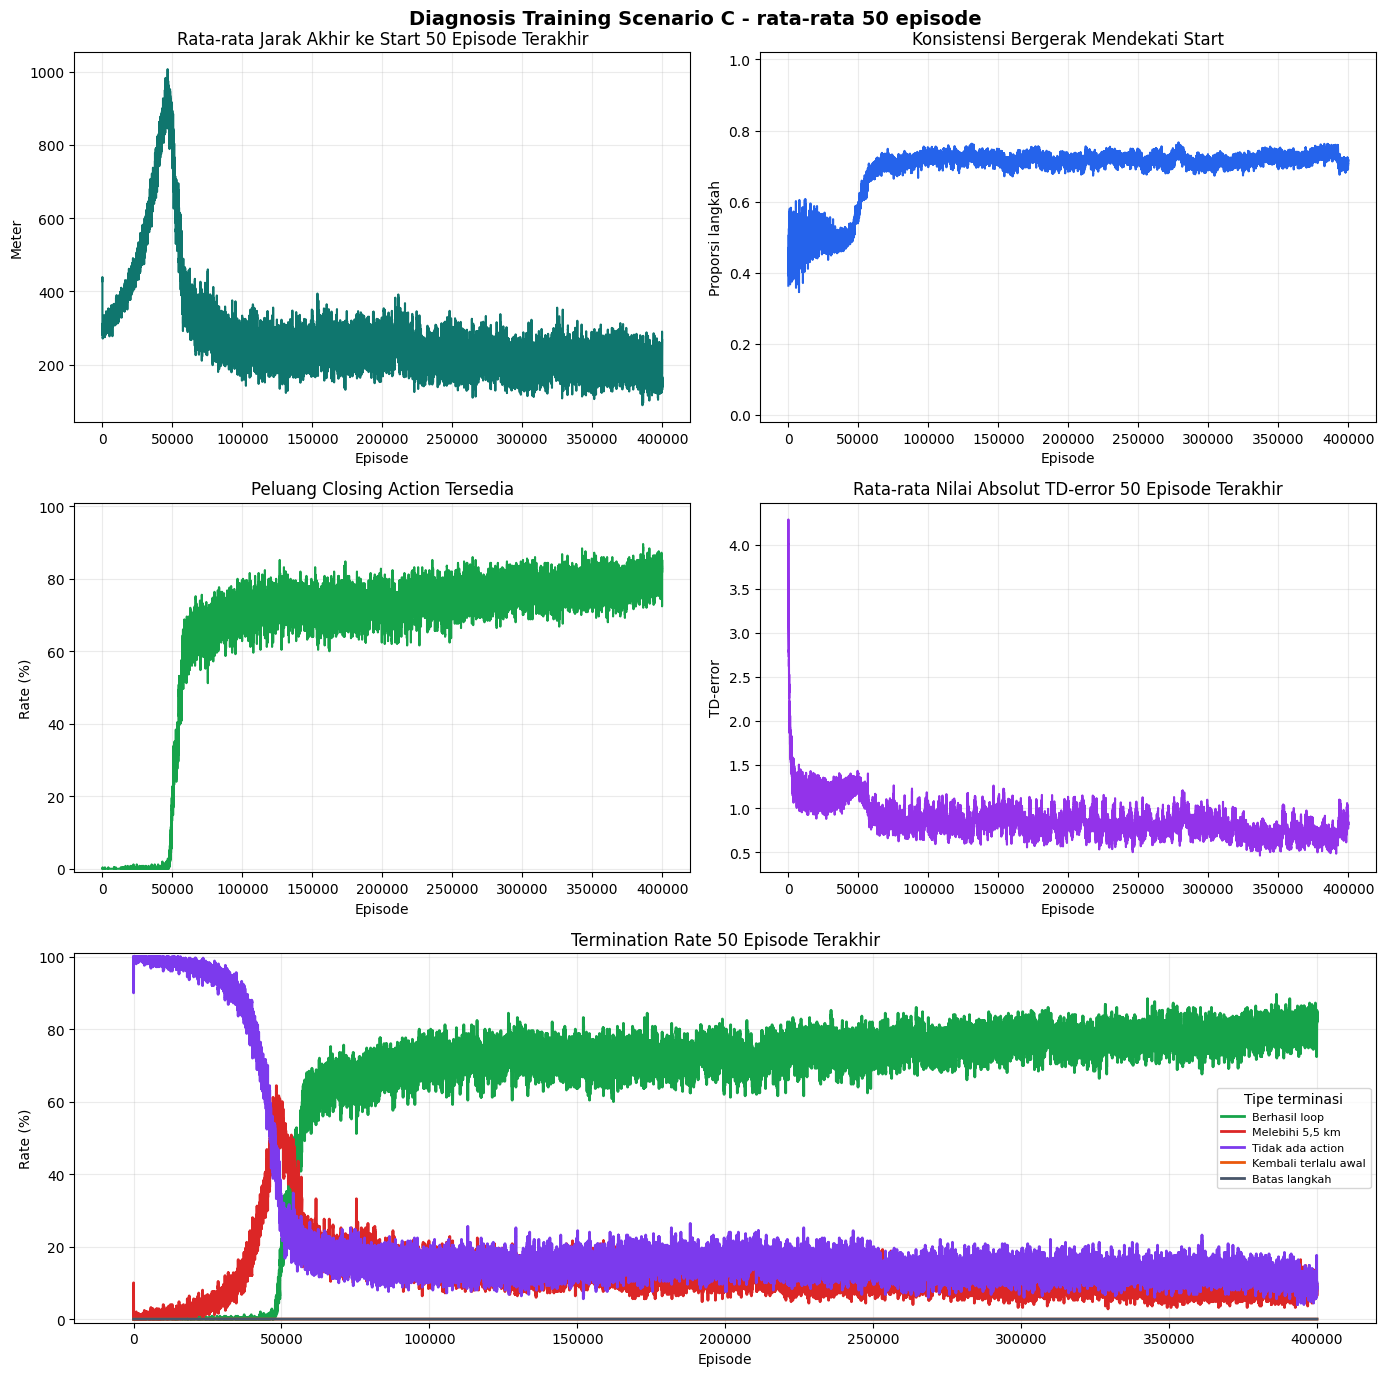

=== Q-TABLE / SEED YANG DIPILIH UNTUK PETA ===
Scenario: C; seed: 2
Metrik: is_loop=True, jarak=4823.66 m, galat=176.34 m, comfort=0.700, return_progress=0.848, jarak akhir ke start=0.00 m, terminasi=success
Alasan: Dipilih dari 5 loop valid: galat jarak paling kecil; jika setara, comfort lalu return progress lebih tinggi.


History: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_epsilon_tetap_50000_episode_400000_C/training_history_C.csv
Evaluasi: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_epsilon_tetap_50000_episode_400000_C/evaluation_metrics_C.csv
Diagnosis: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_epsilon_tetap_50000_episode_400000_C/diagnosis_metrics_C.csv
Termination rate training: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_epsilon_tetap_50000_episode_400000_C/termination_rates_training_C.csv
Termination rate evaluasi: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_epsilon_tetap_50000_episode_400000_C/termination_rates_evaluation_C.csv
G

In [58]:
import importlib
# Memuat ulang core agar parameter epsilon_decay_episodes versi terbaru digunakan.
importlib.reload(rute_lari_core)

result_c_fixed_400000 = rute_lari_core.run_scenario_experiment(
    G, START_NODE, 'C',
    episodes=400_000,
    # Epsilon turun hanya pada 50.000 episode pertama, kemudian tetap 0,05.
    epsilon_decay_episodes=50_000,
    result_subdir='sensitivitas_epsilon_tetap_50000_episode_400000_C',
)


### 3.5 Ringkasan epsilon decay tetap

Tabel dan grafik berikut menggunakan evaluasi greedy lima seed dari setiap jumlah episode. Bandingkan terutama keberhasilan loop, galat jarak, return progress ratio, dan peluang closing action tersedia. TD-error dibaca dari grafik diagnosis masing-masing training, bukan dari tabel ringkasan ini.


,episodes,epsilon_decay_episodes,success_rate_greedy,mean_distance_error_m,mean_total_reward,mean_comfort,mean_return_progress_ratio,closing_action_available_rate
0,50000,50000,0.4,422.306708,4.001773,0.704572,0.615112,0.4
1,100000,50000,1.0,267.312130,87.081832,0.699180,0.785559,1.0
2,200000,50000,1.0,264.159432,86.866042,0.699190,0.770134,1.0
3,400000,50000,1.0,361.899061,81.707673,0.669635,0.750097,1.0


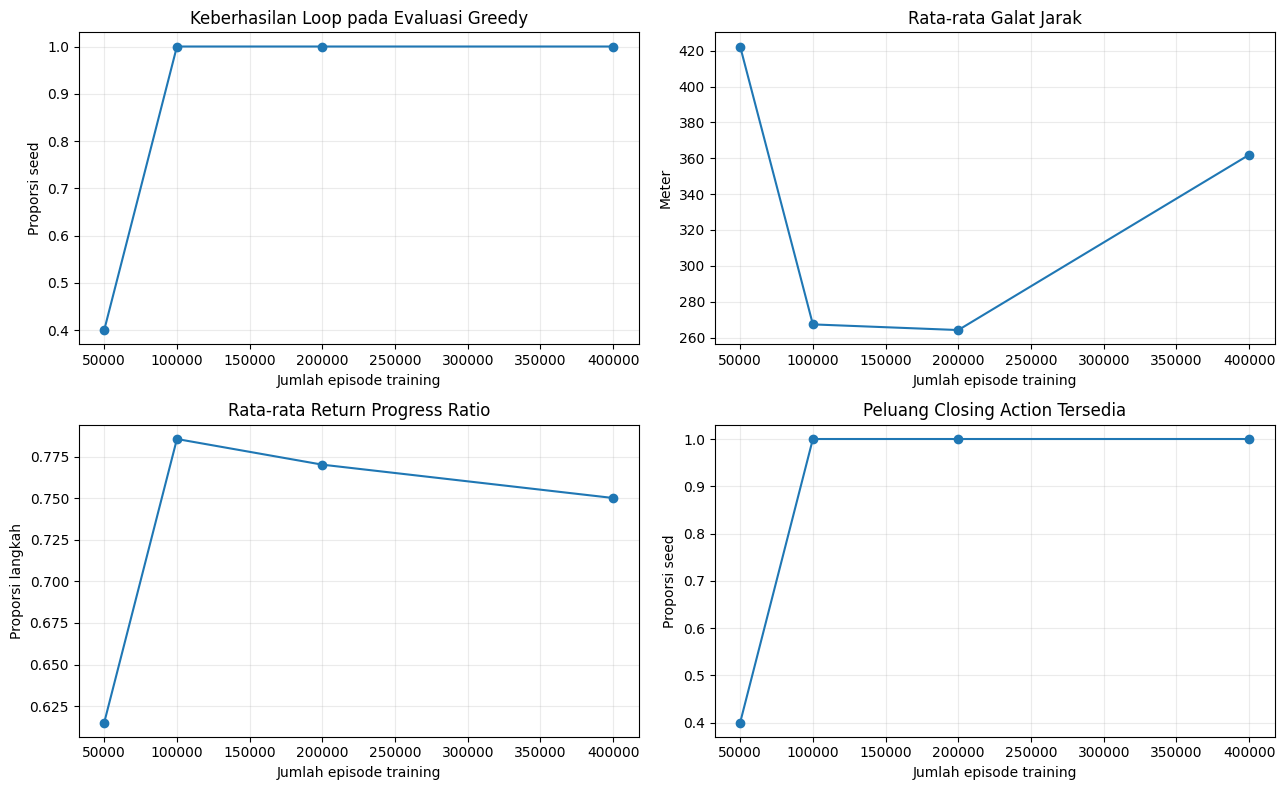

In [60]:
import matplotlib.pyplot as plt
import pandas as pd

# Semua hasil di bawah memakai jadwal epsilon yang sama: turun selama 50.000
# episode pertama, lalu tetap 0,05. Karena itu perbedaan antar titik terutama
# berasal dari tambahan durasi training, bukan dari durasi eksplorasi yang berubah.
fixed_decay_results = {
    50_000: result_c_fixed_50000,
    100_000: result_c_fixed_100000,
    200_000: result_c_fixed_200000,
    400_000: result_c_fixed_400000,
}

summary_rows = []
for episodes, result in fixed_decay_results.items():
    metrics = result['metrics']
    summary_rows.append({
        'episodes': episodes,
        'epsilon_decay_episodes': result['epsilon_decay_episodes'],
        'success_rate_greedy': metrics['is_loop'].mean(),
        'mean_distance_error_m': metrics['absolute_distance_error_m'].mean(),
        'mean_total_reward': metrics['total_reward'].mean(),
        'mean_comfort': metrics['mean_comfort'].mean(),
        'mean_return_progress_ratio': metrics['return_progress_ratio'].mean(),
        'closing_action_available_rate': metrics['closing_action_available'].mean(),
    })

fixed_decay_sensitivity_df = pd.DataFrame(summary_rows).sort_values('episodes')
display(fixed_decay_sensitivity_df)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
plots = [
    ('success_rate_greedy', 'Keberhasilan Loop pada Evaluasi Greedy', 'Proporsi seed'),
    ('mean_distance_error_m', 'Rata-rata Galat Jarak', 'Meter'),
    ('mean_return_progress_ratio', 'Rata-rata Return Progress Ratio', 'Proporsi langkah'),
    ('closing_action_available_rate', 'Peluang Closing Action Tersedia', 'Proporsi seed'),
]
for axis, (column, title, ylabel) in zip(axes.flat, plots):
    axis.plot(
        fixed_decay_sensitivity_df['episodes'],
        fixed_decay_sensitivity_df[column],
        marker='o',
    )
    axis.set(title=title, xlabel='Jumlah episode training', ylabel=ylabel)
    axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 4. Cara membaca hasil evaluasi

Tabel evaluasi utama memuat `is_loop`, `total_distance_m`, `absolute_distance_error_m`, `total_reward`, `mean_comfort`, `return_progress_ratio`, `distance_to_start_at_end_m`, `closing_action_available`, dan `termination_reason`.

Grafik diagnosis tetap membantu menjelaskan proses training, khususnya termination rate dan ketersediaan closing action.

Baca detail seluruh implementasi di `IMPLEMENTASI.md`.